### Read-in downloaded data

In [1]:
import pandas as pd
import pandas_profiling
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
data = pd.read_csv("csv/2021-10-28.csv", index_col = False)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5633602 entries, 0 to 5633601
Data columns (total 21 columns):
viewer_id                        object
broadcaster_id                   object
viewer_age                       float64
viewer_gender                    object
viewer_longitude                 float64
viewer_latitude                  float64
viewer_lang                      object
viewer_country                   object
broadcaster_age                  float64
broadcaster_gender               object
broadcaster_longitude            float64
broadcaster_latitude             float64
broadcaster_lang                 object
broadcaster_country              object
duration                         int64
viewer_network                   object
broadcaster_network              object
count                            int64
broadcast_active_viewer_count    object
viewer_lat_long_cluster          int64
rank                             int64
dtypes: float64(6), int64(4), object(11)
memo

In [5]:
data.describe()

,viewer_age,viewer_longitude,viewer_latitude,broadcaster_age,broadcaster_longitude,broadcaster_latitude,duration,count,viewer_lat_long_cluster,rank
count,5.633602e+06,5.633602e+06,5.633602e+06,5.633602e+06,5.633602e+06,5.633602e+06,5.633602e+06,5.633602e+06,5.633602e+06,5633602.0
mean,3.441093e+01,-4.007065e+01,3.043148e+01,3.103974e+01,-4.589912e+01,3.089025e+01,2.072001e+03,6.936779e+00,2.018583e+00,1.0
std,9.884384e+00,7.864723e+01,1.991731e+01,8.133782e+00,7.841000e+01,1.827696e+01,5.116360e+04,1.564471e+02,2.334296e+00,0.0
min,1.800000e+01,-1.781194e+02,-5.484330e+01,1.800000e+01,-1.781194e+02,-5.430840e+01,4.600000e+01,1.000000e+00,0.000000e+00,1.0
25%,2.700000e+01,-9.050000e+01,2.629500e+01,2.500000e+01,-9.440000e+01,2.711710e+01,9.300000e+01,1.000000e+00,0.000000e+00,1.0
50%,3.300000e+01,-7.700000e+01,3.562890e+01,3.000000e+01,-7.900000e+01,3.509760e+01,1.820000e+02,1.000000e+00,1.000000e+00,1.0
75%,4.000000e+01,-2.560000e-02,4.180000e+01,3.500000e+01,-2.200000e+00,4.170000e+01,5.520000e+02,4.000000e+00,3.000000e+00,1.0
max,2.000000e+02,1.801962e+02,9.100000e+01,1.290000e+02,1.801962e+02,7.570000e+01,5.201024e+07,2.992090e+05,7.000000e+00,1.0


In [6]:
data.head()

,viewer_id,broadcaster_id,viewer_age,viewer_gender,viewer_longitude,viewer_latitude,viewer_lang,viewer_country,broadcaster_age,broadcaster_gender,...,broadcaster_latitude,broadcaster_lang,broadcaster_country,duration,viewer_network,broadcaster_network,count,broadcast_active_viewer_count,viewer_lat_long_cluster,rank
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,33.0,female,-86.6716,37.1323,en,US,37.0,female,...,34.5363,en,US,73,meetme,meetme,1,2021-10-27:26,0,1
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,28.0,male,-86.6716,36.1323,en,US,29.0,female,...,35.0939,en,US,6821,meetme,meetme,16,"2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10...",0,1
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,27.0,male,-86.6716,36.1323,en,US,28.0,female,...,40.7521,en,US,65,meetme,meetme,1,2021-10-28:6,0,1
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,47.0,male,-85.6716,37.1323,en,US,25.0,male,...,38.7856,en,US,72,meetme,meetme,4,"2021-10-28:2,2021-10-28:2",0,1
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,32.0,male,-85.6716,37.1323,en,US,26.0,male,...,34.9000,en,US,64,meetme,pof,4,"2021-10-24:14,2021-10-24:16",0,1


In [7]:
data.columns

Index(['viewer_id', 'broadcaster_id', 'viewer_age', 'viewer_gender',
       'viewer_longitude', 'viewer_latitude', 'viewer_lang', 'viewer_country',
       'broadcaster_age', 'broadcaster_gender', 'broadcaster_longitude',
       'broadcaster_latitude', 'broadcaster_lang', 'broadcaster_country',
       'duration', 'viewer_network', 'broadcaster_network', 'count',
       'broadcast_active_viewer_count', 'viewer_lat_long_cluster', 'rank'],
      dtype='object')

In [9]:
data[['viewer_id', 'broadcaster_id', 'broadcast_active_viewer_count']].head()

,viewer_id,broadcaster_id,broadcast_active_viewer_count
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,2021-10-27:26
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,"2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10..."
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,2021-10-28:6
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,"2021-10-28:2,2021-10-28:2"
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,"2021-10-24:14,2021-10-24:16"


In [8]:
data['viewer_id'].nunique()

773328

In [9]:
data['broadcaster_id'].nunique()

112896

In [10]:
data['pair'] = data['viewer_id'] + "-" + data['broadcaster_id']

In [11]:
data['pair'].nunique()

5400076

In [12]:
data['pair'].nunique()/data.shape[0]

0.9585476574312491

### Remove and fill missing values

In [52]:
df = data.copy()

In [53]:
df.drop(labels=['rank'], axis=1,inplace=True)

In [54]:
df['count'].describe()

count    5.633602e+06
mean     6.936779e+00
std      1.564471e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      4.000000e+00
max      2.992090e+05
Name: count, dtype: float64

In [55]:
len(data[data.isnull().any(axis=1)])/data.shape[0]

0.07144682922222763

In [56]:
data[data.isnull().any(axis=1)]

,viewer_id,broadcaster_id,viewer_age,viewer_gender,viewer_longitude,viewer_latitude,viewer_lang,viewer_country,broadcaster_age,broadcaster_gender,...,broadcaster_latitude,broadcaster_lang,broadcaster_country,duration,viewer_network,broadcaster_network,count,broadcast_active_viewer_count,viewer_lat_long_cluster,rank
9,83 88 d9 2a 38 0d cf ac a7 96 11 48 68 4c b0 8f,9b 69 52 d3 21 ef 79 60 42 bd d5 65 ae ec 99 3a,32.0,male,-86.671600,37.132300,en,US,24.0,female,...,37.1936,en,US,410,meetme,meetme,4,NaN,0,1
16,d9 90 fc d9 d4 45 04 bd 5a 0a 0d 76 8d c7 8c 82,8f 50 09 d8 27 f9 31 d4 24 59 e9 38 5d 3a 29 3f,26.0,male,-86.671600,36.132300,es,US,27.0,male,...,9.8566,es,CR,441,meetme,meetme,1,NaN,0,1
18,bd ce 98 6a 2b 1f 8c 8d 18 06 f3 d4 8f 88 6f 9d,40 9e 13 0b bd 8b 58 3d 65 7f 1d 85 a4 6b 75 43,39.0,male,-86.671600,36.132300,en,US,23.0,female,...,36.9000,en,US,180,meetme,pof,1,NaN,0,1
19,ec ab 8c e9 fd 46 78 34 39 b7 71 08 c9 ce 2e 1a,84 6d d9 6d 4c 67 07 e2 d1 9f 28 91 f6 e4 75 47,22.0,female,-86.671600,36.132300,en,US,27.0,male,...,43.3015,en,US,75,meetme,meetme,1,NaN,0,1
26,1e 7a 55 d4 ea df 54 6f e7 d5 08 4f 64 a7 a1 c1,3a be 1f 9d 5c 2a 7e 3b 91 33 68 50 6a f1 50 4a,39.0,male,-86.671600,37.132300,en,US,42.0,male,...,38.0800,en,US,541,meetme,meetme,1,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5633577,d7 db 4c 1e 39 35 5f 3f 55 93 20 20 d6 b3 e3 0a,46 30 48 c0 f6 1d f8 55 77 30 8d 91 9f d2 59 e0,120.0,female,81.264999,13.090000,en,GB,34.0,male,...,18.3885,en,IN,185,skout,meetme,1,NaN,1,1
5633581,9b 1e 5d e5 c2 d5 09 27 26 2f 6f c7 ec 8b ed 1d,a1 ed cf b6 56 82 32 46 b7 e0 c1 e1 5f af 46 e6,32.0,female,101.578003,14.650000,th,TH,39.0,male,...,13.7080,th,TH,101,skout,skout,1,NaN,6,1
5633589,ec c5 6a 0d 61 af 57 d2 98 0e 17 9a 68 85 cd e3,de f8 95 17 dd 15 da 08 82 1d 83 38 1c 17 af c6,39.0,female,121.957001,15.650000,en,US,36.0,male,...,14.7130,en,PH,370,skout,skout,4,NaN,6,1
5633590,26 8e 56 ae eb e8 8f ac 4a 8a e6 33 12 dd 27 15,cc 9c 34 f7 53 ce e9 fb 3a c5 ec 70 6c 03 90 78,34.0,male,-72.845001,41.890999,en,US,26.0,male,...,41.8410,en,US,1598,skout,skout,1,NaN,0,1


In [57]:
df.dropna(inplace=True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5231099 entries, 0 to 5633601
Data columns (total 20 columns):
viewer_id                        object
broadcaster_id                   object
viewer_age                       float64
viewer_gender                    object
viewer_longitude                 float64
viewer_latitude                  float64
viewer_lang                      object
viewer_country                   object
broadcaster_age                  float64
broadcaster_gender               object
broadcaster_longitude            float64
broadcaster_latitude             float64
broadcaster_lang                 object
broadcaster_country              object
duration                         int64
viewer_network                   object
broadcaster_network              object
count                            int64
broadcast_active_viewer_count    object
viewer_lat_long_cluster          int64
dtypes: float64(6), int64(3), object(11)
memory usage: 838.1+ MB


### broadcasters by viewer_network

In [24]:
df.groupby(['viewer_network'])['broadcaster_id'].nunique()

viewer_network
meetme    78873
pof       57304
skout     69511
zoosk     17505
Name: broadcaster_id, dtype: int64

In [36]:
df.groupby(['viewer_network'])['broadcaster_id'].nunique()/sum(df.groupby(['viewer_network'])['broadcaster_id'].nunique())

viewer_network
meetme    0.353385
pof       0.256746
skout     0.311439
zoosk     0.078430
Name: broadcaster_id, dtype: float64

In [43]:
res = df.groupby(['viewer_network','broadcaster_id'])['count'].sum().to_frame('tot_count').sort_values('tot_count', ascending=False).reset_index()

In [44]:
res.head(20)

,viewer_network,broadcaster_id,tot_count
0,pof,40 e2 06 40 eb 74 8d 2b 20 ba c9 2d 3f 72 3f 25,299923
1,meetme,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,252310
2,skout,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,209204
3,pof,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,98632
4,pof,f0 b6 b1 cd 70 e0 3c 9c ef 83 23 65 5b 39 0b 0d,98387
5,meetme,33 bd 21 f6 0e 9b bd 32 bf e8 a5 7a c8 35 56 25,89777
6,meetme,ac 45 bc 73 fa c4 de a2 c2 33 f4 8f 6f 0e c3 b3,85636
7,meetme,23 6e 9e 23 be bd ac d0 16 3e 27 fd 2f c7 94 3e,83243
8,pof,ac 45 bc 73 fa c4 de a2 c2 33 f4 8f 6f 0e c3 b3,62090
9,meetme,92 56 78 93 91 e0 7b 62 7d 61 94 47 57 ae 91 d2,49683


In [45]:
res.describe()

,tot_count
count,223193.000000
mean,171.224308
std,1281.828674
min,1.000000
25%,4.000000
50%,18.000000
75%,89.000000
max,299923.000000


<AxesSubplot:xlabel='tot_count'>

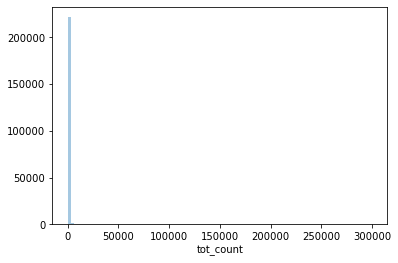

In [89]:
sns.distplot(res['tot_count'], kde = False, bins = 100)

<AxesSubplot:xlabel='viewer_network', ylabel='tot_count'>

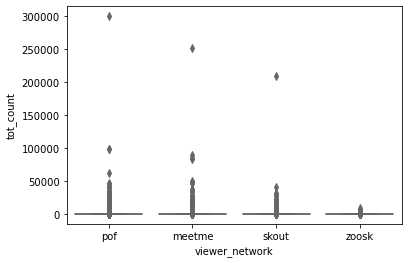

In [90]:
sns.boxplot(x = 'viewer_network',y = 'tot_count',  data = res, palette = 'coolwarm')

In [53]:
res['new'] = res['tot_count'].apply(lambda x: True if x==1 else False)

In [61]:
res['new'].value_counts()/sum(res['new'].value_counts())

False    0.869292
True     0.130708
Name: new, dtype: float64

<AxesSubplot:xlabel='viewer_network', ylabel='tot_count'>

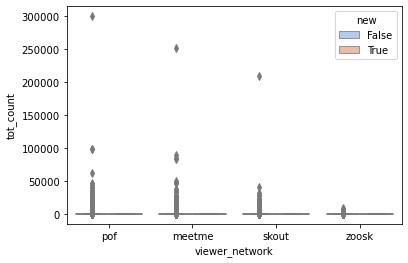

In [92]:
sns.boxplot(x = 'viewer_network',y = 'tot_count', hue ='new', data = res, palette = 'coolwarm')

<AxesSubplot:xlabel='viewer_network', ylabel='tot_count'>

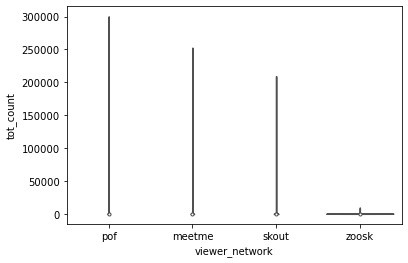

In [94]:
sns.violinplot(x = 'viewer_network', y = 'tot_count', data = res, palette = 'rainbow')

<AxesSubplot:xlabel='viewer_network', ylabel='tot_count'>

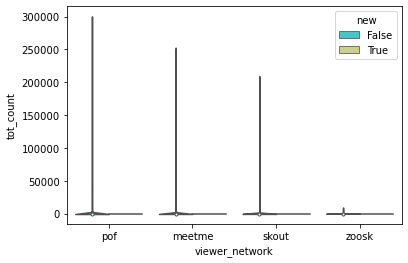

In [95]:
sns.violinplot(x = 'viewer_network', y = 'tot_count', data = res, hue = 'new', palette = 'rainbow')

In [119]:
plot_res = res[res['tot_count']<210]

In [120]:
plot_res.describe()

,tot_count
count,190483.000000
mean,32.757873
std,45.545158
min,1.000000
25%,4.000000
50%,12.000000
75%,42.000000
max,209.000000


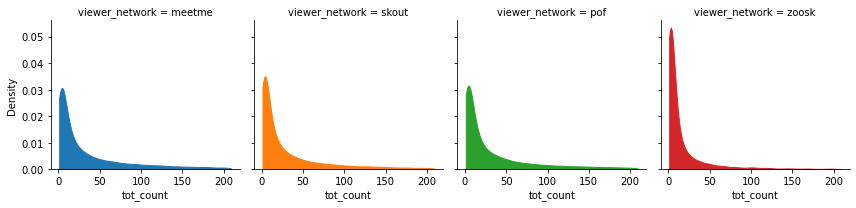

In [121]:
g = sns.FacetGrid(plot_res, col='viewer_network', hue='viewer_network', col_wrap=4)
g = g.map(sns.kdeplot, "tot_count", cut=0, fill=True, common_norm=False, alpha=1, legend=False)
plt.show()

In [123]:
190483/223193

0.8534452245366118

In [125]:
top_res = res[res['tot_count']>=210]

In [126]:
top_res['viewer_network'].value_counts().reset_index().sort_values('viewer_network', ascending=False).reset_index()

,level_0,index,viewer_network
0,0,meetme,13931
1,1,pof,9825
2,2,skout,8341
3,3,zoosk,613


In [128]:
top_res.head()

,viewer_network,broadcaster_id,tot_count,new
0,pof,40 e2 06 40 eb 74 8d 2b 20 ba c9 2d 3f 72 3f 25,299923,False
1,meetme,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,252310,False
2,skout,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,209204,False
3,pof,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,98632,False
4,pof,f0 b6 b1 cd 70 e0 3c 9c ef 83 23 65 5b 39 0b 0d,98387,False


In [129]:
top_res.sort_values("tot_count", ascending=False)

,viewer_network,broadcaster_id,tot_count,new
0,pof,40 e2 06 40 eb 74 8d 2b 20 ba c9 2d 3f 72 3f 25,299923,False
1,meetme,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,252310,False
2,skout,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,209204,False
3,pof,e1 cb 61 0f 14 b2 a4 fc bc d8 7d 12 12 65 06 f1,98632,False
4,pof,f0 b6 b1 cd 70 e0 3c 9c ef 83 23 65 5b 39 0b 0d,98387,False
...,...,...,...,...
32628,pof,94 22 36 40 04 93 58 84 c9 93 29 cb bf f5 43 a9,210,False
32627,skout,0d 35 19 75 51 a6 07 7f 64 d0 f1 c3 0b 28 93 19,210,False
32626,skout,17 46 8d 0e c4 cc b0 14 bf fd 9c 46 60 d6 87 fa,210,False
32625,skout,27 fb 63 5c 7e 8a d8 d5 3d ed bd 38 04 e6 bf 70,210,False


In [130]:
32710/223193

0.1465547754633882

### TFIDF

Inverse frequency factors into the equation because interactions with less popular broadcasters provide more information about the viewers than interactions with popular broadcasters.

tf, the term frequency, 

In [78]:
df_tf = df.groupby(['broadcaster_id'])['count'].sum().to_frame('tf').reset_index()

In [79]:
tf_mapping = df_tf.set_index('broadcaster_id')['tf'].to_dict()

In [80]:
df['tf'] = df['count']/df['broadcaster_id'].map(tf_mapping)

In [81]:
df[['viewer_id', 'broadcaster_id', 'count','tf']].head()

,viewer_id,broadcaster_id,count,tf
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,1,0.000209
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,16,0.003699
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,1,0.004673
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,4,0.000962
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,4,0.000254


idf, the inverse document frequency,

In [82]:
N = df['viewer_id'].nunique()

In [83]:
N

744947

In [84]:
df_idf = df.groupby(['viewer_id'])['broadcaster_id'].count().to_frame('df').reset_index()

In [85]:
from math import log10
df_idf['idf'] = df_idf['df'].apply(lambda x: round(1 + log10(N / (1 + x)), 3))

In [86]:
idf_mapping = df_idf.set_index('viewer_id')['idf'].to_dict()

In [87]:
df['idf'] = df['viewer_id'].map(idf_mapping)

In [88]:
df['tfidf'] = df[['tf', 'idf']].apply(lambda x: x[0] * x[1], axis=1)

In [89]:
df[['viewer_id', 'broadcaster_id', 'count','tf', 'idf', 'tfidf']].head()

,viewer_id,broadcaster_id,count,tf,idf,tfidf
0,99 a1 08 11 6c 34 6b 98 33 1e 29 d9 99 09 4d 8d,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,1,0.000209,6.027,0.001257
1,e4 ce 91 be 08 70 c2 a6 a7 4e d4 51 a9 0e 84 67,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,16,0.003699,5.281,0.019532
2,33 47 6e 09 04 7a 6f 93 a6 81 90 09 27 9d 87 b9,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,1,0.004673,5.425,0.025350
3,5f 4e 1a e0 28 93 1c 98 cd 35 85 5c 39 b6 ac ec,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,4,0.000962,4.964,0.004775
4,e1 91 07 68 40 d1 59 e0 49 e0 01 37 e1 be cc c4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,4,0.000254,5.425,0.001380


In [90]:
df['tfidf'].describe()

count    5.231099e+06
mean     9.556282e-02
std      4.099215e-01
min      7.921898e-06
25%      2.874290e-03
50%      1.006845e-02
75%      3.920210e-02
max      6.571000e+00
Name: tfidf, dtype: float64

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

In [93]:
plt_df = df[df['tfidf'] < df['tfidf'].quantile(.9)]

<AxesSubplot:title={'center':'The density plot of tfidf'}, ylabel='Frequency'>

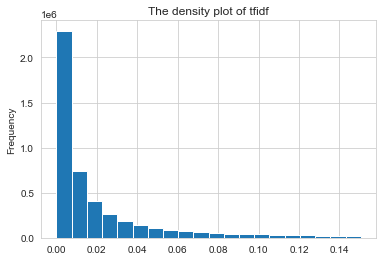

In [94]:
plt_df['tfidf'].plot(kind='hist', title="The density plot of tfidf", bins=20)

In [59]:
plt_df = df[['viewer_network', 'count', 'tfidf']].sample(frac=0.01)

In [60]:
plt_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52311 entries, 3974919 to 3279527
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   viewer_network  52311 non-null  object 
 1   count           52311 non-null  int64  
 2   tfidf           52311 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ MB


(0.0, 1.0)

<Figure size 1200x800 with 0 Axes>

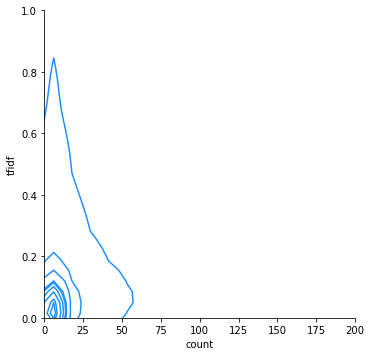

In [79]:
plt.figure(figsize=(15,10), dpi= 80)
sns.displot(data=plt_df, x="count", y="tfidf", kind="kde", color="dodgerblue")
plt.xlim(0, 200)
plt.ylim(0, 1)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.6/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Users/lhuang/opt/miniconda3/envs/tensorflow2.6/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Users/lhuang/opt/miniconda3/envs/tensorflow2.6/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to

(0.0, 1.5)

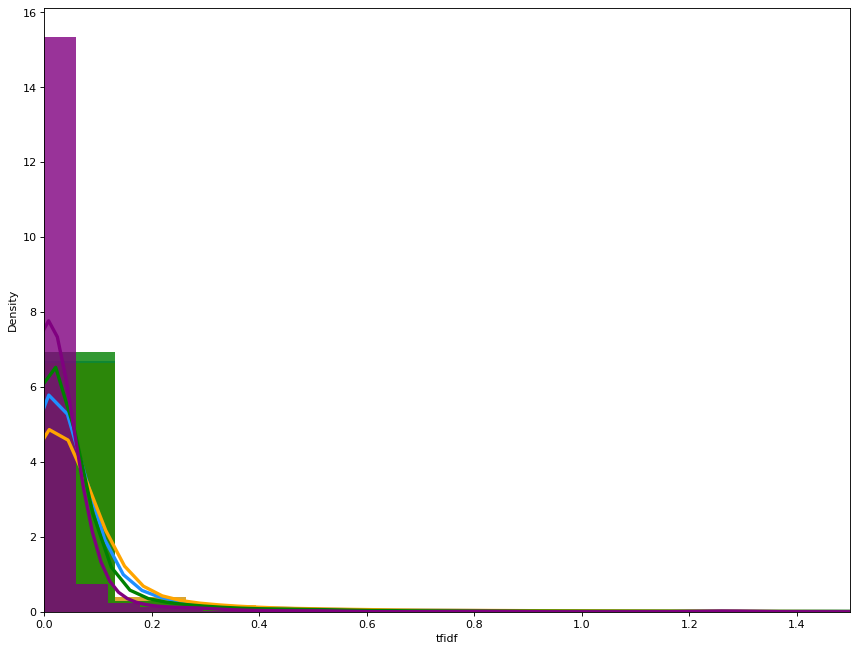

In [77]:
plt.figure(figsize=(13,10), dpi= 80)
sns.distplot(plt_df.loc[df['viewer_network'] == 'meetme', "tfidf"], color="dodgerblue", label="Meetme", hist_kws={'alpha':.8}, kde_kws={'linewidth':3})
sns.distplot(plt_df.loc[df['viewer_network'] == 'skout', "tfidf"], color="orange", label="Skout", hist_kws={'alpha':.8}, kde_kws={'linewidth':3})
sns.distplot(plt_df.loc[df['viewer_network'] == 'pof', "tfidf"], color="green", label="Pof", hist_kws={'alpha':.8}, kde_kws={'linewidth':3})
sns.distplot(plt_df.loc[df['viewer_network'] == 'zoosk', "tfidf"], color="purple", label="Zoosk", hist_kws={'alpha':.8}, kde_kws={'linewidth':3})
plt.xlim(0, 1.5)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.6/lib/python3.7/site-packages/seaborn/axisgrid.py:2076: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


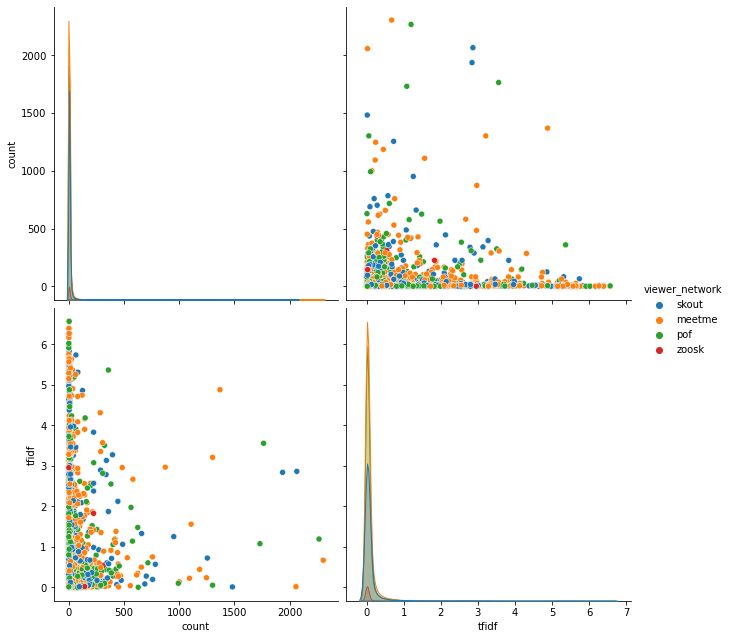

In [85]:
sns.pairplot(plt_df, hue='viewer_network', size=4.5);

### weight decays for broadcast_active_viewer_count

In [41]:
plt_data = pd.DataFrame({"x":np.linspace(1, 8, 8), "y":1/np.linspace(1, 8, 8)})

In [42]:
plt_data

,x,y
0,1.0,1.000000
1,2.0,0.500000
2,3.0,0.333333
3,4.0,0.250000
4,5.0,0.200000
5,6.0,0.166667
6,7.0,0.142857
7,8.0,0.125000


Text(0, 0.5, 'decay scores')

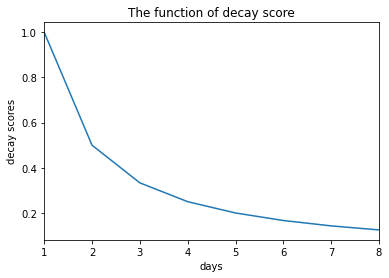

In [50]:
ax = plt_data.plot(x="x", y="y", title="The function of decay score",legend=False)
ax.set_xlabel("days")
ax.set_ylabel("decay scores")

In [59]:
df.columns

Index(['viewer_id', 'broadcaster_id', 'viewer_age', 'viewer_gender',
       'viewer_longitude', 'viewer_latitude', 'viewer_lang', 'viewer_country',
       'broadcaster_age', 'broadcaster_gender', 'broadcaster_longitude',
       'broadcaster_latitude', 'broadcaster_lang', 'broadcaster_country',
       'duration', 'viewer_network', 'broadcaster_network', 'count',
       'broadcast_active_viewer_count', 'viewer_lat_long_cluster'],
      dtype='object')

In [60]:
df['broadcast_active_viewer_count']

0                                              2021-10-27:26
1          2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10...
2                                               2021-10-28:6
3                                  2021-10-28:2,2021-10-28:2
4                                2021-10-24:14,2021-10-24:16
                                 ...                        
5633597                                         2021-10-25:5
5633598                                         2021-10-22:7
5633599                                        2021-10-25:13
5633600                                        2021-10-26:11
5633601    2021-10-24:9,2021-10-24:22,2021-10-24:13,2021-...
Name: broadcast_active_viewer_count, Length: 5231099, dtype: object

In [61]:
samples = df.sample(n=10)

In [62]:
from datetime import datetime, timedelta

In [63]:
date_format = '%Y-%m-%d'
date_format_full = '%Y-%m-%d %H:%M:%S'

def dt_to_str(date, dateformat):
    """Convert Python datetime.datetime object to string YYYY-MM-DD."""
    return date.strftime(dateformat)

def dt_from_str(date, dateformat):
    """Convert string YYYY-MM-DD to Python datetime.datetime object."""
    return datetime.strptime(date, dateformat)

In [64]:
dt_to_str(datetime.now(), date_format)

'2021-11-09'

In [65]:
end_dt = dt_from_str('2021-10-29', date_format)

In [66]:
def add_broadcast_active_viewer_columns(df):
    weights = [1/i for i in range(1, 9)]
    res = []
#     min_dt, max_dt = end_dt, end_dt
    for k, v in enumerate(df['broadcast_active_viewer_count']):
        if len(v) > 0:
            sourcemap = {}
            for item in v.split(","):
                if ":" in item:
                    dt, cnt = item.split(":")
                    cnt = int(cnt)
                    visit_dt = dt_from_str(dt, date_format)
                    delta = end_dt - visit_dt
#                     max_dt = max(visit_dt, max_dt)
#                     min_dt = min(visit_dt, min_dt)
                    if dt not in sourcemap:
                        sourcemap[dt] = weights[delta.days-1] * cnt
                    else:
                        sourcemap[dt] += weights[delta.days-1] * cnt
            res.append(sum(sourcemap.values()))
        else:
            res.append(0)
#     print(min_dt, max_dt)
    return res

In [67]:
df['decay_broadcast_active_viewer_count'] = add_broadcast_active_viewer_columns(df)

In [70]:
df[['broadcaster_id', 'broadcast_active_viewer_count', 'decay_broadcast_active_viewer_count']].head()

,broadcaster_id,broadcast_active_viewer_count,decay_broadcast_active_viewer_count
0,81 4b b8 b5 3b a9 17 72 c8 98 7b 6b b0 22 4e 79,2021-10-27:26,13.0
1,52 96 80 73 d8 4c 86 88 e1 5a e9 24 0f 1d 87 8f,"2021-10-22:3,2021-10-22:2,2021-10-22:2,2021-10...",15.8
2,b5 34 be 75 38 09 61 65 c6 9d 63 09 11 2e dd 23,2021-10-28:6,6.0
3,b6 01 4e fa d4 4b 03 df ff c2 07 7b 1f c6 af e5,"2021-10-28:2,2021-10-28:2",4.0
4,18 16 f8 f2 e7 3e 76 ac 24 01 c8 86 75 71 b6 ec,"2021-10-24:14,2021-10-24:16",6.0


In [71]:
df['decay_broadcast_active_viewer_count'].describe()

count    5.231099e+06
mean     1.142629e+01
std      8.478651e+01
min      1.250000e-01
25%      1.000000e+00
50%      2.333333e+00
75%      7.000000e+00
max      5.064686e+04
Name: decay_broadcast_active_viewer_count, dtype: float64

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

<AxesSubplot:ylabel='Frequency'>

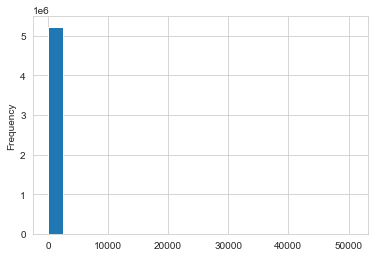

In [74]:
df['decay_broadcast_active_viewer_count'].plot(kind='hist', bins=20)

In [75]:
plt_df = df[df['decay_broadcast_active_viewer_count'] < df['decay_broadcast_active_viewer_count'].quantile(.9)]

<AxesSubplot:title={'center':'The density plot of decay_broadcast_active_viewer_count'}, ylabel='Frequency'>

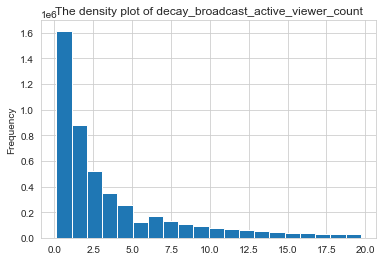

In [77]:
plt_df['decay_broadcast_active_viewer_count'].plot(kind='hist', title="The density plot of decay_broadcast_active_viewer_count", bins=20)

In [99]:
plt_df = df[df['decay_broadcast_active_viewer_count'] < 10]

In [100]:
plt_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4247617 entries, 2 to 5633600
Data columns (total 25 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   viewer_id                            object 
 1   broadcaster_id                       object 
 2   viewer_age                           float64
 3   viewer_gender                        object 
 4   viewer_longitude                     float64
 5   viewer_latitude                      float64
 6   viewer_lang                          object 
 7   viewer_country                       object 
 8   broadcaster_age                      float64
 9   broadcaster_gender                   object 
 10  broadcaster_longitude                float64
 11  broadcaster_latitude                 float64
 12  broadcaster_lang                     object 
 13  broadcaster_country                  object 
 14  duration                             int64  
 15  viewer_network                  

In [101]:
plt_df = plt_df[['viewer_network', 'decay_broadcast_active_viewer_count', 'tfidf']].sample(frac=0.01)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.6/lib/python3.7/site-packages/seaborn/axisgrid.py:2076: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


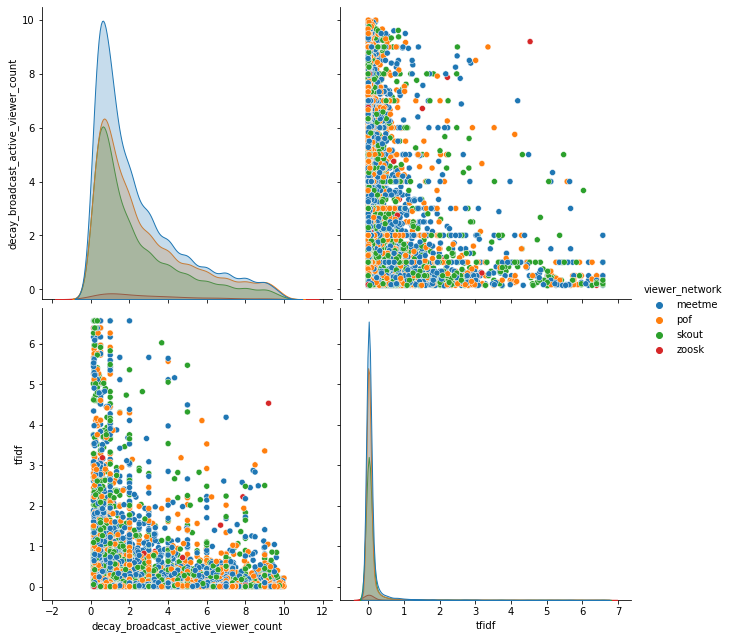

In [102]:
sns.pairplot(plt_df, hue='viewer_network', size=4.5);